<a href="https://colab.research.google.com/github/luisrodriguezh-crypto/-Clasificaci-n-del-Riesgo-de-Diabetes-en-Poblaci-n-Mexican/blob/main/Proyecto_Diabetes_Mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>Proyecto Final — Clasificación del Riesgo de Diabetes en Población Mexicana</h2>

<h3>
Dataset:
<strong>
<a href="https://www.kaggle.com/datasets/frederickfelix/diabetes-mexico-data-set" target="_blank">
Diabetes Mexico Data Set (ENSANUT 2024)
</a>
</strong>
</h3>

<p><strong>Variable objetivo:</strong> <code>riesgo_diabetes_cat</code></p>

<hr>

<h2>Introducción</h2>

<p>
México ocupa uno de los primeros lugares mundiales en prevalencia de diabetes tipo 2.
La Encuesta Nacional de Salud y Nutrición 2022 documentó que aproximadamente
<strong>uno de cada diez adultos mexicanos vive con diabetes diagnosticada</strong>,
y que un porcentaje similar permanece sin diagnóstico
(<a href="https://saludpublica.mx/index.php/spm/article/view/15081" target="_blank">
Basto-Abreu et al., 2023</a>).
Esta carga epidemiológica impone una presión directa sobre el sistema de salud público
y demanda herramientas capaces de identificar tempranamente a los individuos en mayor riesgo,
antes de que la enfermedad se manifieste clínicamente.
</p>

<p>
La detección temprana ha demostrado ser clínicamente efectiva: intervenciones
preventivas aplicadas en etapas de prediabetes o riesgo moderado pueden retrasar
o incluso evitar la progresión a diabetes tipo 2
(<a href="https://diabetesjournals.org/care/article/47/Supplement_1/S20/153954" target="_blank">
American Diabetes Association, 2024</a>).
Sin embargo, el acceso a pruebas bioquímicas de laboratorio sigue siendo
limitado en regiones rurales y comunidades de bajos ingresos en México,
donde precisamente la prevalencia de factores de riesgo es más alta.
</p>

<p>
En este contexto, el presente proyecto plantea la siguiente pregunta de investigación:
<strong>¿es posible predecir el nivel de riesgo de diabetes utilizando únicamente variables
no invasivas y fácilmente accesibles — sin pruebas de laboratorio?</strong>
Si un modelo puede inferir el riesgo a partir de variables sociodemográficas,
hábitos de vida y condiciones de salud autorreportadas, podría aplicarse en
tamizajes comunitarios a gran escala, orientando recursos preventivos donde más se necesitan.
</p>

<p>
Para responder esta pregunta se utilizan los microdatos de la
<strong>Encuesta Nacional de Salud y Nutrición Continua 2024 (ENSANUT Continua 2024)</strong>,
desarrollada por el Instituto Nacional de Salud Pública
(<a href="https://ensanut.insp.mx/encuestas/ensanutcontinua2024/index.php" target="_blank">
INSP, 2024</a>).
Esta encuesta, diseñada con representatividad nacional y muestreo estratificado,
integra en un mismo instrumento variables sociodemográficas, hábitos de vida,
antecedentes clínicos y mediciones antropométricas y bioquímicas —
lo que la convierte en la fuente más completa disponible públicamente
para estudiar el riesgo metabólico en población mexicana
(<a href="https://saludpublica.mx/index.php/spm/article/download/16455/12621/83835" target="_blank">
Romero-Martínez et al., 2024</a>).
</p>

<p>
La variable objetivo <code>riesgo_diabetes_cat</code> clasifica a los individuos
en tres niveles de riesgo construidos a partir de criterios clínicos de la
Asociación Americana de Diabetes — la organización de referencia internacional
en diagnóstico y clasificación de diabetes
(<a href="https://doi.org/10.2337/dc24-S002" target="_blank">ADA, 2024</a>):
</p>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Clase</th>
            <th>Etiqueta</th>
            <th>Significado clínico</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>0</strong></td>
            <td>Bajo / sin riesgo</td>
            <td>Ausencia de factores clínicamente relevantes según criterios ADA</td>
        </tr>
        <tr>
            <td><strong>1</strong></td>
            <td>Riesgo moderado</td>
            <td>Presencia de sobrepeso o alteraciones leves en glucosa</td>
        </tr>
        <tr>
            <td><strong>2</strong></td>
            <td>Riesgo alto</td>
            <td>Combinación de obesidad y alteraciones glucémicas — criterios ADA de prediabetes</td>
        </tr>
    </tbody>
</table>

<p>
Una decisión metodológica central en este análisis consiste en excluir deliberadamente
las variables utilizadas en la <em>construcción</em> de la variable objetivo —
IMC, glucosa en suero y HbA1c. Incluirlas introduciría un problema de
<em>data leakage</em>: el modelo aprendería directamente las reglas clínicas
que definen la etiqueta, produciendo métricas artificialmente elevadas
sin validez predictiva real en nuevos pacientes.
Este riesgo metodológico ha sido ampliamente documentado en estudios de
aprendizaje automático aplicados a salud
(<a href="https://www.nature.com/articles/s41746-020-00300-0" target="_blank">
Sendak et al., 2020</a>).
</p>

<p>
Se implementan y comparan <strong>seis modelos de clasificación</strong>
que abarcan desde métodos lineales hasta ensambles y redes neuronales,
siguiendo la arquitectura de evaluación comparativa propuesta por
<a href="http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf" target="_blank">
Tai, Wu y Hinojosa (2020)</a> en su trabajo sobre clasificación multiclase
con desbalance — incluyendo balanced sampling y AUC macro como métrica principal.
</p>

<hr>

<p style="font-size: 0.9em; color: #555;">
<strong>Fuente del dataset:</strong>
Félix, F. (2024). <em>Diabetes Mexico Data Set (ENSANUT 2024)</em> [Dataset]. Kaggle.
Dataset derivado de la ENSANUT Continua 2024, Instituto Nacional de Salud Pública (INSP), México.
</p>

## 0. Importación de Librerías

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)



In [16]:

df = pd.read_csv('Diabetes_Mexico.csv')
print(f'Shape: {df.shape[0]:,} filas  ×  {df.shape[1]} columnas')
df.head()


Shape: 2,549 filas  ×  24 columnas


,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
0,2024_01001010,2024_01001010_01,Mujer,89.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"4,1",...,"0,62",166.0,"4,7",107.0,NaN,"2245,917738",3.0,13.0,"2888,530238",2
1,2024_01001012,2024_01001012_01,Mujer,71.0,AGUASCALIENTES,NaN,NaN,32.0,1.0,"4,3",...,"0,64",98.0,"9,6",132.0,NaN,"2245,917738",3.0,13.0,"2888,530238",1
2,2024_01001016,2024_01001016_02,Mujer,57.0,AGUASCALIENTES,"80,25","170,6",NaN,1.0,"4,9",...,"0,6",128.0,"4,7",263.0,6.0,"4047,445276",3.0,13.0,NaN,2
3,2024_01001016,2024_01001016_05,Mujer,20.0,AGUASCALIENTES,"68,6","166,2",NaN,1.0,"4,9",...,"0,63",112.0,"10,1",238.0,NaN,"13079,14232",3.0,13.0,"13776,80526",2
4,2024_01001031,2024_01001031_01,Hombre,74.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"6,4",...,"1,09",97.0,"10,2",135.0,NaN,"5292,158204",3.0,13.0,"5824,779445",0


<h2>2. Contexto del Problema y Diccionario de Variables</h2>

<p>
El dataset integra variables de tres dimensiones fundamentales:
<strong>sociodemográficas</strong> (edad, sexo, nivel socioeconómico),
<strong>hábitos y estilo de vida</strong> (actividad física, consumo de tabaco y alcohol)
y <strong>clínicas</strong> (antecedentes familiares, comorbilidades y mediciones de salud).
Esta diversidad responde a la naturaleza multifactorial de la diabetes tipo 2,
cuyo desarrollo involucra la interacción simultánea de factores biológicos,
conductuales y sociales
(<a href="https://diabetesjournals.org/care/article/47/Supplement_1/S20/153954" target="_blank">
ADA, 2024</a>).
</p>

<p>
Este enfoque multidimensional resulta especialmente relevante para el contexto mexicano.
La ENSANUT 2022 documentó que los factores de riesgo más prevalentes en la población adulta
incluyen el sobrepeso y la obesidad (presentes en más del 75% de los adultos),
la actividad física insuficiente y los antecedentes familiares de diabetes
(<a href="https://saludpublica.mx/index.php/spm/article/view/15081" target="_blank">
Basto-Abreu et al., 2023</a>).
Estos patrones epidemiológicos respaldan la decisión de incluir variables de hábitos
y condición socioeconómica como predictores del riesgo, alineándose con evidencia
previa que demuestra que modelos no invasivos pueden alcanzar desempeño clínicamente
útil en tamizaje poblacional
(<a href="https://doi.org/10.2337/diacare.27.5.1047" target="_blank">Bang et al., 2004</a>).
</p>

<h3>Variables excluidas — prevención de fuga de información (<em>data leakage</em>)</h3>

<p>
La variable objetivo <code>riesgo_diabetes_cat</code> fue construida a partir
de los criterios diagnósticos de la Asociación Americana de Diabetes
(<a href="https://doi.org/10.2337/dc24-S002" target="_blank">ADA, 2024</a>),
que definen prediabetes y diabetes en función de valores de glucosa en ayuno,
hemoglobina glucosilada (HbA1c) e índice de masa corporal (IMC).
Incluir estas variables como predictoras introduciría data leakage directo:
el modelo reconstruiría la regla clínica de etiquetado en lugar de aprender
patrones subyacentes generalizables.
</p>

<p>
Este tipo de error metodológico — que produce métricas artificialmente elevadas
sin valor predictivo real — ha sido identificado como uno de los problemas
más frecuentes en estudios de aprendizaje automático aplicado a salud
Su exclusión hace el problema más difícil, pero también más honesto
y útil en la práctica clínica real, donde la etiqueta no existe y debe inferirse.
</p>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Grupo</th>
            <th>Variables excluidas</th>
            <th>Justificación</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Identificadores</td>
            <td><code>folio_i</code>, <code>folio_int</code></td>
            <td>No contienen información predictiva — son folios administrativos</td>
        </tr>
        <tr>
            <td>Diseño muestral</td>
            <td><code>muestra_suero</code>, <code>ponde_venosa</code>,
                <code>estrato</code>, <code>est_sel</code>, <code>ponde_hemo</code></td>
            <td>Variables del diseño de la encuesta, no del individuo</td>
        </tr>
        <tr>
            <td><strong>Data leakage</strong></td>
            <td><code>imc</code>, <code>Peso</code>, <code>Estatura</code></td>
            <td>Definen el criterio de obesidad del ADA utilizado en la etiqueta</td>
        </tr>
        <tr>
            <td><strong>Data leakage</strong></td>
            <td><code>glu_suero</code>, <code>hb1ac</code></td>
            <td>Definen la alteración glucémica del ADA utilizada en la etiqueta</td>
        </tr>
    </tbody>
</table>

## 3. Exploración Inicial del Dataset

<p>
Antes de modelar un problema de <strong>clasificación</strong>, primero debemos auditar la calidad de los datos.
Aquí no solo interesa saber cuántas filas y columnas existen, sino también:
<strong>tipos de variable</strong>, <strong>porcentaje de valores faltantes</strong>,
<strong>duplicados</strong>, cardinalidad de variables categóricas y señales tempranas de ruido.
Esta revisión justifica el uso posterior de <strong>imputación</strong> y evita construir modelos sobre supuestos incorrectos.
</p>

<p>
En particular, si existen valores <code>NaN</code>, no conviene eliminarlos de forma automática porque podríamos perder
información valiosa y alterar la distribución de clases. Como este proyecto es de clasificación,
la estrategia más estable es imputar:
<strong>mediana</strong> para variables numéricas y <strong>moda</strong> para variables categóricas,
siempre ajustando esos estadísticos únicamente con el conjunto de entrenamiento para evitar
<strong>data leakage</strong>.
</p>


INFO GENERAL DEL DATASET
════════════════════════════════════════════════════════════════════════════════
Filas: 2,549
Columnas: 24
Duplicados exactos: 0



,Variable,Tipo,No_nulos,NaN,% NaN,Únicos,Ejemplo
7,imc,float64,35,2514,98.63,17,32.0
18,hb1ac,float64,241,2308,90.55,8,6.0
22,ponde_hemo,object,1569,980,38.45,1480,"2888,530238"
6,Estatura,object,1829,720,28.25,413,"170,6"
5,Peso,object,1829,720,28.25,961,"80,25"
19,ponde_venosa,object,2450,99,3.88,2294,"2245,917738"
3,edad,float64,2524,25,0.98,77,89.0
4,Ciudad,object,2549,0,0.00,267,AGUASCALIENTES
9,ac_urico,object,2549,0,0.00,89,"4,1"
10,albu,object,2549,0,0.00,44,"3,1"


RESUMEN DE VALORES FALTANTES
────────────────────────────────────────────────────────────────────────────────
Total de celdas NaN en el dataset : 7,366
Columnas con al menos un NaN      : 7/24


,Variable,Tipo,NaN,% NaN
0,imc,float64,2514,98.63
1,hb1ac,float64,2308,90.55
2,ponde_hemo,object,980,38.45
3,Estatura,object,720,28.25
4,Peso,object,720,28.25
5,ponde_venosa,object,99,3.88
6,edad,float64,25,0.98


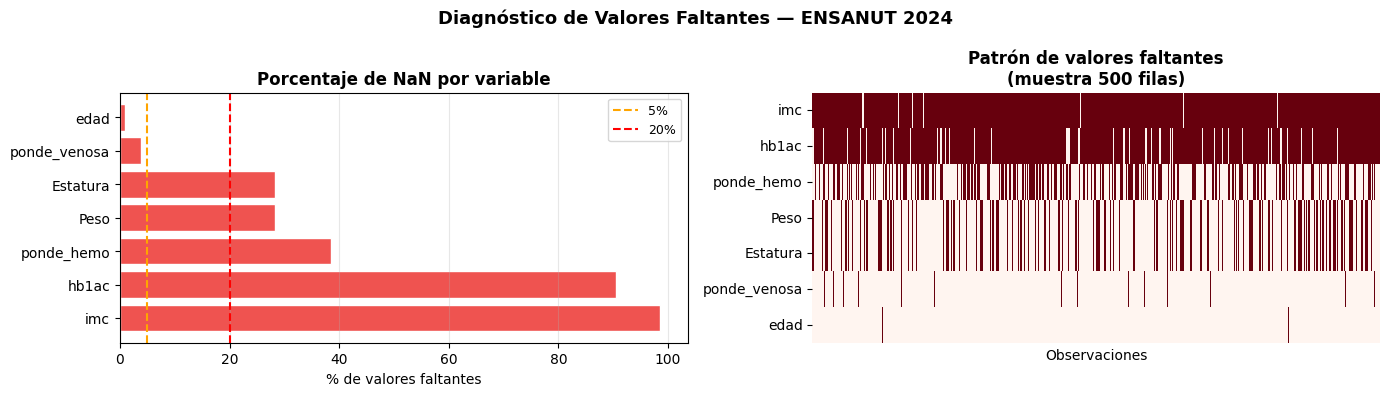


Estrategia de imputación:
  imc                            (numérica   ) → Mediana  [98.6% NaN]
  hb1ac                          (numérica   ) → Mediana  [90.5% NaN]
  ponde_hemo                     (categórica ) → Moda  [38.5% NaN]
  Peso                           (categórica ) → Moda  [28.2% NaN]
  Estatura                       (categórica ) → Moda  [28.2% NaN]
  ponde_venosa                   (categórica ) → Moda  [3.9% NaN]
  edad                           (numérica   ) → Mediana  [1.0% NaN]

Conclusión: se utiliza imputación dentro del Pipeline para evitar data leakage.

TIPOS DE VARIABLES
────────────────────────────────────────────────────────────────────────────────
Variables numéricas            : 11
Variables categóricas          : 13


,count,mean,std,min,25%,50%,75%,max
edad,2524.0,35.763,319.673,-7975.0,34.0,47.5,62.0,95.0
imc,35.0,29.971,7.633,15.0,25.0,30.0,32.5,56.0
muestra_suero,2549.0,1.000,0.000,1.0,1.0,1.0,1.0,1.0
col_ldl,2549.0,91.144,29.905,16.0,71.0,88.0,108.0,354.0
colest,2549.0,143.023,42.458,25.0,115.0,139.0,166.0,625.0
glu_suero,2549.0,105.541,51.922,32.0,83.0,92.0,104.0,1116.0
trig,2549.0,153.564,126.311,24.0,87.0,123.0,181.0,2834.0
hb1ac,241.0,5.809,1.451,5.0,5.0,5.0,6.0,12.0
estrato,2549.0,2.089,0.825,1.0,1.0,2.0,3.0,3.0
est_sel,2549.0,167.799,94.421,11.0,83.0,172.0,242.0,323.0


In [17]:
print('INFO GENERAL DEL DATASET')
print('═' * 80)
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'Duplicados exactos: {df.duplicated().sum():,}')
print()

# ── Resumen estructural ───────────────────────────────────────
resumen_cols = pd.DataFrame({
    'Variable':  df.columns,
    'Tipo':      df.dtypes.astype(str).values,
    'No_nulos':  df.notna().sum().values,
    'NaN':       df.isna().sum().values,
    '% NaN':     (df.isna().mean().values * 100).round(2),
    'Únicos':    [df[c].nunique(dropna=True) for c in df.columns],
    'Ejemplo':   [df[c].dropna().iloc[0] if df[c].notna().any()
                  else 'Todo NaN' for c in df.columns]
}).sort_values(by=['% NaN', 'NaN', 'Variable'], ascending=[False, False, True])

display(resumen_cols)

total_nan    = int(df.isna().sum().sum())
cols_con_nan = int((df.isna().sum() > 0).sum())

print('RESUMEN DE VALORES FALTANTES')
print('─' * 80)
print(f'Total de celdas NaN en el dataset : {total_nan:,}')
print(f'Columnas con al menos un NaN      : {cols_con_nan}/{df.shape[1]}')

# ── Visualización de NaN ──────────────────────────────────────
nan_por_col = df.isna().sum()
nan_por_col = nan_por_col[nan_por_col > 0].sort_values(ascending=False)

if len(nan_por_col) > 0:
    tabla_nan = (
        resumen_cols.loc[resumen_cols['NaN'] > 0,
                         ['Variable', 'Tipo', 'NaN', '% NaN']]
        .reset_index(drop=True)
    )
    display(tabla_nan)

    # Heatmap de valores faltantes
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Barplot % NaN por columna
    nan_por_col_pct = (nan_por_col / len(df) * 100).round(2)
    axes[0].barh(nan_por_col_pct.index, nan_por_col_pct.values,
                 color='#EF5350', edgecolor='white')
    axes[0].set_xlabel('% de valores faltantes')
    axes[0].set_title('Porcentaje de NaN por variable', fontweight='bold')
    axes[0].axvline(5,  color='orange', ls='--', lw=1.5, label='5%')
    axes[0].axvline(20, color='red',    ls='--', lw=1.5, label='20%')
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    # Matriz de nulidad (muestra aleatoria de 500 filas)
    sample_df = df.sample(min(500, len(df)), random_state=42)
    null_matrix = sample_df[nan_por_col.index].isna()
    sns.heatmap(null_matrix.T, cbar=False, cmap='Reds',
                yticklabels=True, xticklabels=False, ax=axes[1])
    axes[1].set_title('Patrón de valores faltantes\n(muestra 500 filas)',
                      fontweight='bold')
    axes[1].set_xlabel('Observaciones')

    plt.suptitle('Diagnóstico de Valores Faltantes — ENSANUT 2024',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nEstrategia de imputación:')
    for col in nan_por_col.index:
        tipo = 'numérica' if df[col].dtype in [np.float64, np.int64] else 'categórica'
        estrategia = 'Mediana' if tipo == 'numérica' else 'Moda'
        pct = nan_por_col_pct[col]
        print(f'  {col:<30} ({tipo:<11}) → {estrategia}  [{pct:.1f}% NaN]')
    print('\nConclusión: se utiliza imputación dentro del Pipeline para evitar data leakage.')
else:
    print('Conclusión: no se detectaron valores faltantes;')
    print('el imputador se conserva por robustez y reproducibilidad.')

print()
print('TIPOS DE VARIABLES')
print('─' * 80)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Variables numéricas            : {len(num_cols)}')
print(f'Variables categóricas          : {len(cat_cols)}')
if len(num_cols) > 0:
    display(df[num_cols].describe().T.round(3).head(15))

## 4. Distribución de la Variable Objetivo y Análisis de Desbalance

<p>
Verificar el balance entre clases es el primer paso crítico antes de entrenar cualquier
clasificador. En el dominio epidemiológico, el desbalance es la norma: las condiciones
de salud severas son naturalmente menos frecuentes que la ausencia de patología.
</p>

<p>
Tai, Wu y Hinojosa (2020), en su estudio de clasificación de rutas de escalada
en el Moonboard, documentaron empíricamente las consecuencias de ignorar este problema:
sin corrección, los modelos clásicos colapsan sobre las clases mayoritarias y las
clases minoritarias alcanzan <em>F1 = 0.00</em>
(<a href="http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf" target="_blank">
Tai et al., 2020</a>).
En nuestro contexto, ese escenario se traduciría en un clasificador que siempre
predice "sin riesgo" — maximizando el accuracy global pero siendo clínicamente inútil
para la detección temprana.
</p>

<p>
Basto-Abreu et al. (2023) reportaron en ENSANUT 2022 que la prevalencia de diabetes
diagnosticada en adultos mexicanos es de aproximadamente 10.3%, mientras que
la prediabetes (riesgo moderado) afecta a un porcentaje adicional significativo
de la población
(<a href="https://saludpublica.mx/index.php/spm/article/view/15081" target="_blank">
Basto-Abreu et al., 2023</a>).
Esta distribución asimétrica hace esperable que la clase de riesgo alto sea la menos
representada en nuestros datos — lo que confirma la necesidad del balanceo
que se implementa en la sección 7.
</p>

,Clase,Conteo,%
0,Bajo,1697,66.58
1,Moderado,12,0.47
2,Alto,840,32.95


Imbalance ratio: 141.42x


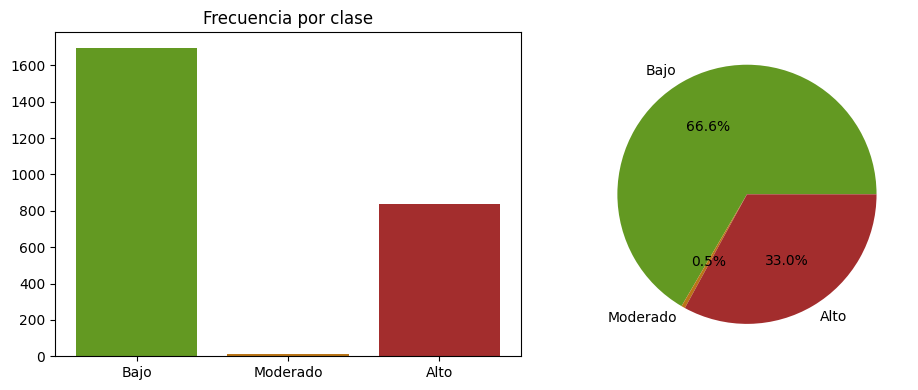

In [18]:
TARGET = 'riesgo_diabetes_cat'

labels = {0: 'Bajo', 1: 'Moderado', 2: 'Alto'}
colors = ['#639922', '#BA7517', '#A32D2D']

# Conteos y proporciones
counts = df[TARGET].value_counts().sort_index()
props = counts / counts.sum() * 100

# Tabla resumen
summary = pd.DataFrame({
    'Clase': [labels[i] for i in counts.index],
    'Conteo': counts.values,
    '%': props.round(2).values
})

display(summary)

# Imbalance
print(f"Imbalance ratio: {counts.max() / counts.min():.2f}x")

# Gráficas
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Barras
ax[0].bar(summary['Clase'], summary['Conteo'], color=colors)
ax[0].set_title('Frecuencia por clase')

# Pie
ax[1].pie(summary['Conteo'], labels=summary['Clase'],
          autopct='%1.1f%%', colors=colors)

plt.tight_layout()
plt.show()

## 5. Selección de Variables y Prevención de Fuga de Información

<p>
Esta es la <strong>decisión metodológica más importante</strong> del proyecto.
Un modelo entrenado con variables que definieron su propia etiqueta no resuelve
el problema original: solo aprende a reconstruir la regla de etiquetado.
Su accuracy parecería excelente, pero al aplicarlo a nuevos pacientes — donde
la etiqueta no existe — simplemente fallaría.
</p>

<p>
Excluir estas variables hace el problema más difícil, pero también más honesto
y útil en la práctica clínica real.
</p>


In [19]:
DROP = [
    'folio_i','folio_int',
    'muestra_suero','ponde_venosa','estrato','est_sel','ponde_hemo',
    'imc','glu_suero','hb1ac','Peso','Estatura'
]

# Selección de variables
df_model = df.drop(columns=DROP).copy()
FEATURES = [c for c in df_model.columns if c != TARGET]

print(f'Features: {len(FEATURES)} | Shape: {df_model.shape}')

Features: 11 | Shape: (2549, 12)


## 5.5. Análisis Exploratorio Adicional

<p>
Antes de modelar conviene hacerse una pregunta concreta: <strong>¿hay señales predictivas
reales en las variables que conservamos?</strong> Si las distribuciones de las variables
numéricas son prácticamente idénticas entre las tres clases de riesgo, ningún modelo
podrá hacer clasificaciones significativas — el problema estaría mal planteado desde
el inicio.
</p>

<p>
Los boxplots por clase y la matriz de correlación nos permiten responder esta pregunta
antes de entrenar un solo modelo.
</p>


Variables numéricas (4): ['edad', 'col_ldl', 'colest', 'trig']
Variables categóricas (7): ['sexo', 'Ciudad', 'ac_urico', 'albu', 'col_hdl', 'creat', 'insulina']


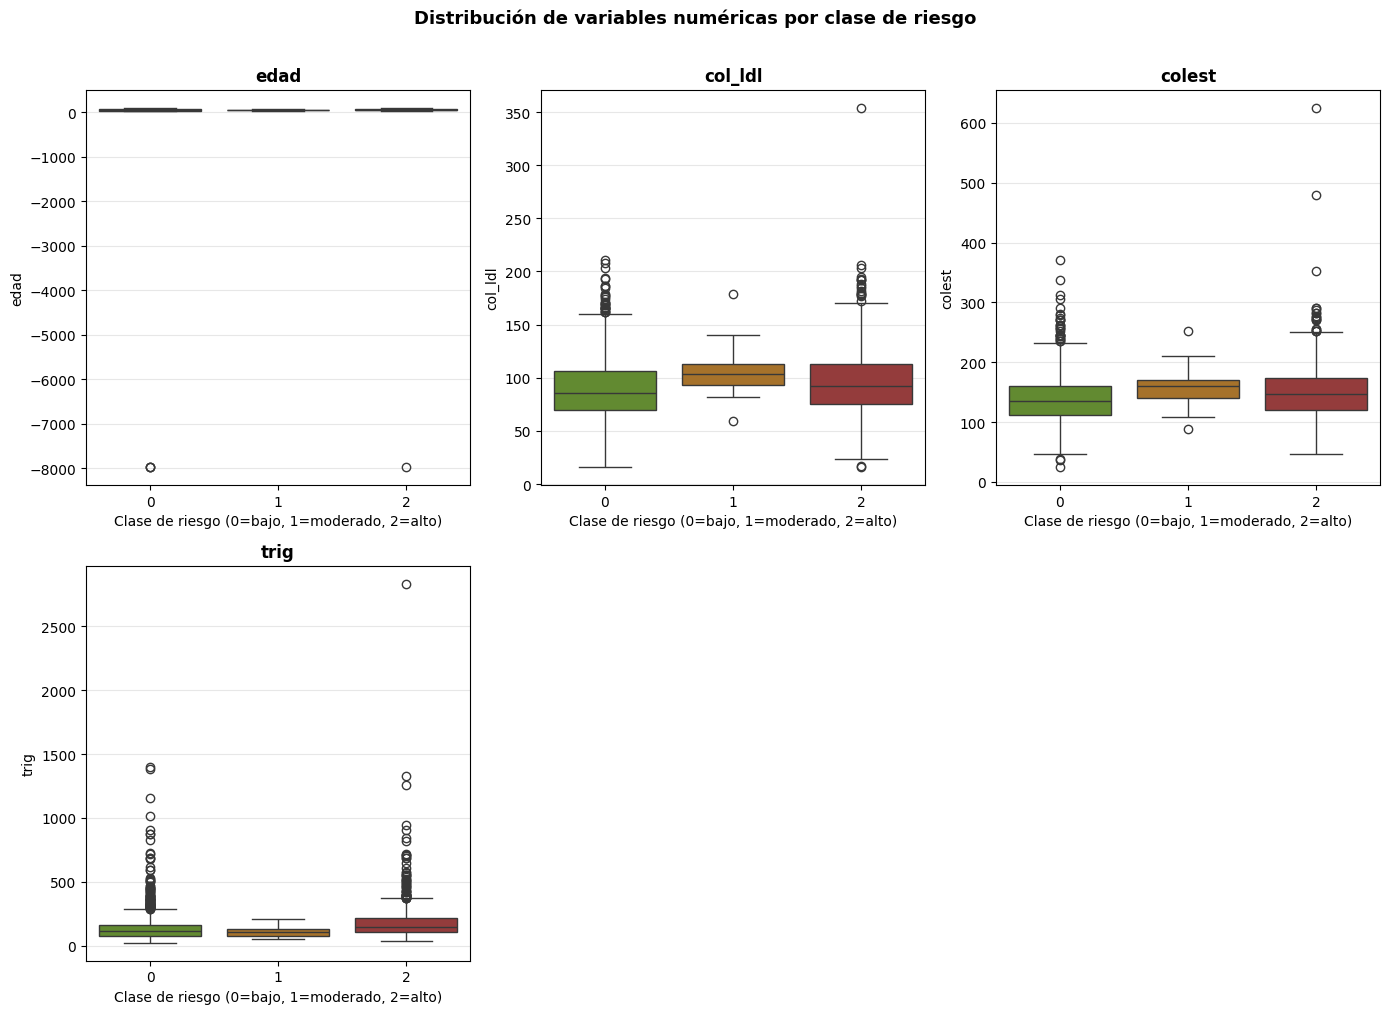

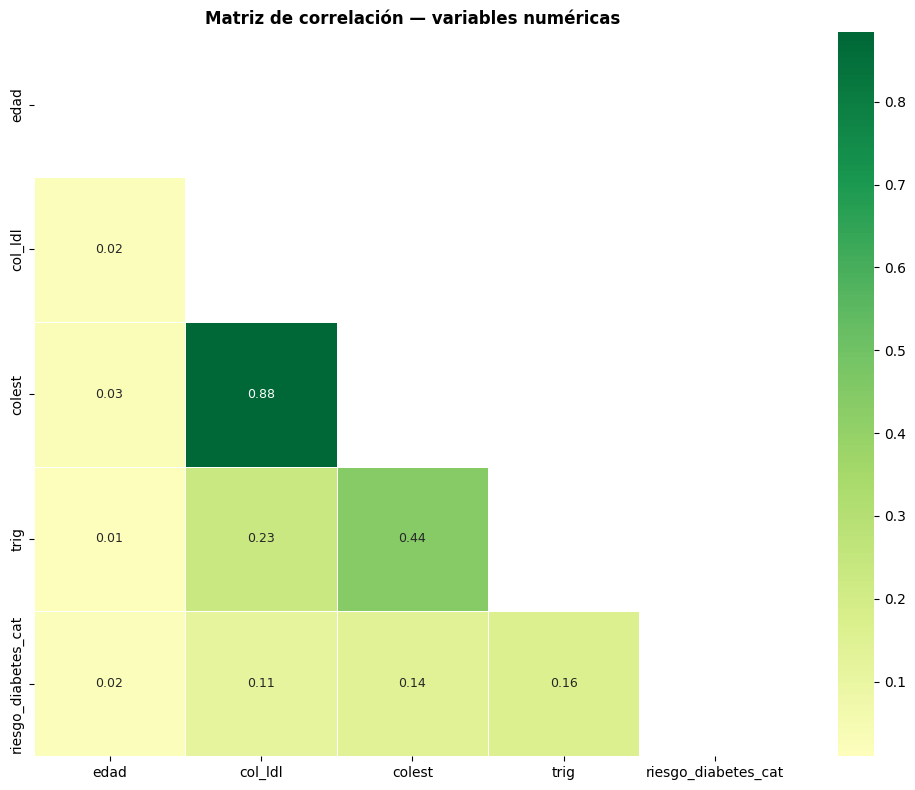

In [20]:
numeric_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns if c != TARGET]
cat_cols     = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Variables numéricas ({len(numeric_cols)}): {numeric_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

# ── Boxplots por clase ────────────────────────────────────────
if len(numeric_cols) > 0:
    n_plot   = min(6, len(numeric_cols))
    sel_cols = numeric_cols[:n_plot]
    nrows    = 2 if n_plot > 3 else 1
    ncols    = min(3, n_plot)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes_flat = np.array(axes).flatten()

    palette = {'0': '#639922', '1': '#BA7517', '2': '#A32D2D'}

    for i, col in enumerate(sel_cols):
        sns.boxplot(data=df_model, x=TARGET, y=col, palette=palette, ax=axes_flat[i])
        axes_flat[i].set_title(col, fontweight='bold')
        axes_flat[i].set_xlabel('Clase de riesgo (0=bajo, 1=moderado, 2=alto)')
        axes_flat[i].grid(axis='y', alpha=0.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle('Distribución de variables numéricas por clase de riesgo',
                 fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# ── Matriz de correlación ─────────────────────────────────────
if len(numeric_cols) >= 3:
    corr = df_model[numeric_cols + [TARGET]].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
    ax.set_title('Matriz de correlación — variables numéricas', fontweight='bold')
    plt.tight_layout()
    plt.show()


## 6. Partición Estratificada Entrenamiento / Prueba

<p>
La partición <strong>80/20 estratificada</strong> garantiza que la proporción de clases
sea la misma en entrenamiento y en prueba. Es el equivalente al
<code>StratifiedShuffleSplit</code> que usamos en A2.2 para la clasificación estelar,
con la misma motivación: si la prueba tuviera una distribución de clases distinta
a la del entrenamiento, la evaluación reflejaría diferencias en la muestra,
no en el modelo.
</p>

<p>
El conjunto de prueba se reserva completamente y no participa en ninguna etapa
de entrenamiento, balanceo ni ajuste de hiperparámetros.
</p>


In [21]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'Conjunto de entrenamiento : {X_train.shape[0]:,} filas ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Conjunto de prueba        : {X_test.shape[0]:,}  filas ({X_test.shape[0]/len(df)*100:.1f}%)')

print('\nDistribución en entrenamiento:')
for cls, cnt in y_train.value_counts().sort_index().items():
    print(f'  {labels[cls]:20s}: {cnt:,}  ({cnt/len(y_train)*100:.1f}%)')

print('\nDistribución en prueba:')
for cls, cnt in y_test.value_counts().sort_index().items():
    print(f'  {labels[cls]:20s}: {cnt:,}  ({cnt/len(y_test)*100:.1f}%)')

Conjunto de entrenamiento : 2,039 filas (80.0%)
Conjunto de prueba        : 510  filas (20.0%)

Distribución en entrenamiento:
  Bajo                : 1,357  (66.6%)
  Moderado            : 10  (0.5%)
  Alto                : 672  (33.0%)

Distribución en prueba:
  Bajo                : 340  (66.7%)
  Moderado            : 2  (0.4%)
  Alto                : 168  (32.9%)


## 7. Balanceo del Conjunto de Entrenamiento — Upsampling

<p>
La estrategia de balanceo adoptada en este proyecto sigue directamente el protocolo
de Tai, Wu y Hinojosa (2020), quienes demostraron en su trabajo de clasificación
de escalada que el balanced sampling es condición necesaria para que los modelos
clásicos detecten clases minoritarias. En su estudio, la clase más difícil
(V14 — la ruta más compleja) pasó de F1 = 0.00 sin balanceo a valores detectables
con upsampling, confirmando que la técnica no solo mejora métricas sino que
transforma cualitativamente la capacidad del modelo
(<a href="http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf" target="_blank">
Tai et al., 2020</a>).
Adoptamos esa misma lógica aquí, aplicada al contexto de salud pública:
sin balanceo, el modelo nunca detectaría individuos de riesgo alto —
precisamente los que más necesitan intervención preventiva.
</p>

<p>
El upsampling se aplica <strong>exclusivamente sobre el conjunto de entrenamiento</strong>,
preservando intacto el conjunto de prueba. Esta distinción es fundamental:
la distribución de prueba refleja la realidad epidemiológica — si en la población
el riesgo alto es menos frecuente, el modelo debe ser evaluado en esas condiciones reales,
no en condiciones artificialmente igualadas.
</p>

                     Original  Balanceado
riesgo_diabetes_cat                      
0                        1357        1357
1                          10        1357
2                         672        1357


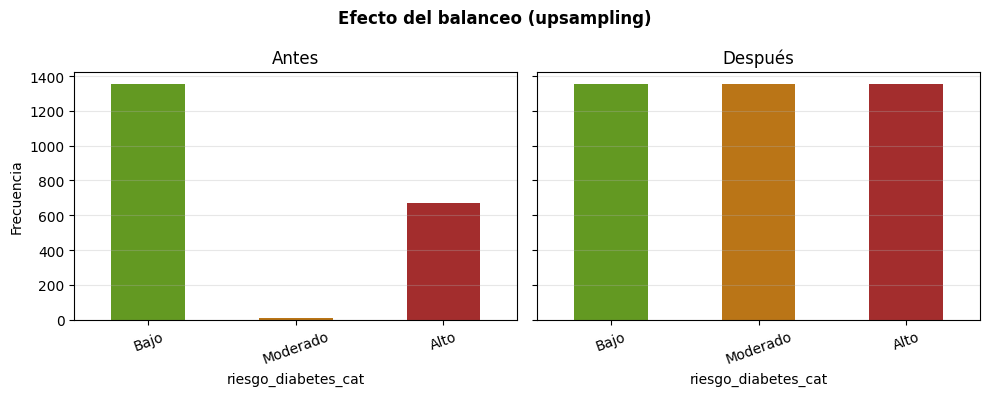

In [22]:
# Tamaño de la clase mayoritaria
max_count = y_train.value_counts().max()

X_train_bal_list = []
y_train_bal_list = []

# Upsampling por clase
for class_label in y_train.unique():
    X_class = X_train[y_train == class_label]
    y_class = y_train[y_train == class_label]

    # Resample the current class to match the majority class size
    X_upsampled, y_upsampled = resample(
        X_class, y_class,
        replace=True,     # Sample with replacement
        n_samples=max_count, # Target size for each class
        random_state=42   # For reproducible results
    )
    X_train_bal_list.append(X_upsampled)
    y_train_bal_list.append(y_upsampled)

# Concatenate all upsampled DataFrames/Series and shuffle them
X_train_bal = pd.concat(X_train_bal_list).sample(frac=1, random_state=42).reset_index(drop=True)
y_train_bal = pd.concat(y_train_bal_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Resumen de distribución
dist = pd.DataFrame({
    'Original': y_train.value_counts().sort_index(),
    'Balanceado': y_train_bal.value_counts().sort_index()
}).fillna(0).astype(int)

print(dist)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharey=True)

dist['Original'].plot(kind='bar', ax=ax[0], color=colors, title='Antes')
dist['Balanceado'].plot(kind='bar', ax=ax[1], color=colors, title='Después')

for a in ax:
    a.set_xticklabels([labels[int(i)] for i in dist.index], rotation=20)
    a.set_ylabel('Frecuencia')
    a.grid(axis='y', alpha=0.3)

plt.suptitle('Efecto del balanceo (upsampling)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Preprocesamiento con Pipeline e Imputación

<p>
Como el objetivo es una <strong>clasificación multiclase</strong>, el preprocesamiento debe ser
<strong>consistente</strong>, <strong>reproducible</strong> y libre de fuga de información.
Por eso encapsulamos todo en un <strong>Pipeline de scikit-learn</strong>.
Así, los parámetros de imputación y escalamiento se ajustan <em>solo con entrenamiento</em>
y después se aplican al conjunto de prueba sin recalcular nada.
</p>

<ul>
<li><strong>Variables numéricas:</strong> imputación por <strong>mediana</strong> (más robusta ante asimetrías y outliers) → <strong>StandardScaler</strong>.</li>
<li><strong>Variables categóricas:</strong> imputación por <strong>moda</strong> → <strong>One-Hot Encoding</strong>.</li>
</ul>

<p>
Esta decisión es especialmente importante si el dataset contiene <code>NaN</code>.
Eliminar filas completas podría reducir innecesariamente la muestra y desbalancear aún más las clases.
En cambio, imputar conserva la mayor cantidad posible de observaciones útiles para el entrenamiento.
</p>


In [23]:
numeric_features     = X_train_bal.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_bal.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Variables numéricas    ({len(numeric_features)}): {numeric_features}')
print(f'Variables categóricas  ({len(categorical_features)}): {categorical_features}')
print()

# Auditoría de NaN antes de imputar
nan_train = X_train_bal.isna().sum()
nan_test  = X_test.isna().sum()

tabla_imputacion = pd.DataFrame({
    'Variable': X_train_bal.columns,
    'Tipo': X_train_bal.dtypes.astype(str).values,
    'NaN_train': nan_train.values,
    '%NaN_train': (nan_train.values / len(X_train_bal) * 100).round(2),
    'NaN_test': nan_test.reindex(X_train_bal.columns, fill_value=0).values,
    '%NaN_test': (nan_test.reindex(X_train_bal.columns, fill_value=0).values / len(X_test) * 100).round(2),
    'Estrategia': [
        'Mediana' if c in numeric_features else 'Moda'
        for c in X_train_bal.columns
    ]
}).sort_values(by=['%NaN_train', 'NaN_train', 'Variable'], ascending=[False, False, True])

display(tabla_imputacion)

if (tabla_imputacion['NaN_train'] > 0).any() or (tabla_imputacion['NaN_test'] > 0).any():
    print('Se detectaron valores faltantes y serán imputados automáticamente dentro del Pipeline.')
else:
    print('No se detectaron NaN en train/test, pero se mantiene el imputador para robustez.')

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Variables numéricas    (4): ['edad', 'col_ldl', 'colest', 'trig']
Variables categóricas  (7): ['sexo', 'Ciudad', 'ac_urico', 'albu', 'col_hdl', 'creat', 'insulina']



,Variable,Tipo,NaN_train,%NaN_train,NaN_test,%NaN_test,Estrategia
1,edad,float64,14,0.34,9,1.76,Mediana
2,Ciudad,object,0,0.00,0,0.00,Moda
3,ac_urico,object,0,0.00,0,0.00,Moda
4,albu,object,0,0.00,0,0.00,Moda
5,col_hdl,object,0,0.00,0,0.00,Moda
6,col_ldl,float64,0,0.00,0,0.00,Mediana
7,colest,float64,0,0.00,0,0.00,Mediana
8,creat,object,0,0.00,0,0.00,Moda
9,insulina,object,0,0.00,0,0.00,Moda
0,sexo,object,0,0.00,0,0.00,Moda


Se detectaron valores faltantes y serán imputados automáticamente dentro del Pipeline.


## 9. Función de Evaluación Unificada

<p>
Para garantizar comparaciones justas, todos los modelos pasan por exactamente la misma
función de evaluación. Las cinco métricas elegidas cubren dimensiones complementarias:
</p>

| Métrica | ¿Qué mide? | ¿Por qué importa aquí? |
|---------|-----------|------------------------|
| **Accuracy** | Proporción global de aciertos | Referencia general |
| **Precision ponderada** | Calidad de las predicciones positivas | Evitar falsas alarmas |
| **Recall ponderado** | Cobertura de los casos reales | Especialmente crítico en clase 2 |
| **F1-score ponderado** | Balance entre precision y recall | Métrica principal en clases desbalanceadas |
| **AUC macro OvR** | Capacidad discriminativa promedio | Métrica central de Tai et al. (2020) |

<p>
El <strong>AUC macro</strong> es particularmente valioso porque evalúa la capacidad
discriminativa del modelo independientemente del umbral de decisión, y promedia
el desempeño entre las tres clases sin dar más peso a la clase mayoritaria.
</p>


In [24]:
resultados = []
modelos_entrenados = {}
roc_resultados = {}

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, verbose=True):
    # Entrena y evalúa un modelo de clasificación, guarda métricas y artefactos ROC.
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te) if hasattr(modelo, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te,   y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te,       y_pred, average='weighted', zero_division=0)

    if y_prob is not None:
        y_te_bin  = label_binarize(y_te, classes=np.sort(np.unique(y_te)))
        auc_score = roc_auc_score(y_te_bin, y_prob, average='macro', multi_class='ovr')
    else:
        auc_score = np.nan

    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(acc, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1-score':  round(f1, 4),
        'AUC':       round(auc_score, 4) if not np.isnan(auc_score) else np.nan,
    })

    modelos_entrenados[nombre] = modelo
    roc_resultados[nombre] = {
        'y_test': pd.Series(y_te).reset_index(drop=True),
        'y_pred': pd.Series(y_pred).reset_index(drop=True),
        'y_prob': y_prob
    }

    if verbose:
        print(f'\n{"═"*58}')
        print(f'  {nombre}')
        print(f'{"═"*58}')
        print(f'  Accuracy  : {acc:.4f}     Precision : {prec:.4f}')
        print(f'  Recall    : {rec:.4f}     F1-score  : {f1:.4f}')
        print(f'  AUC macro : {auc_score:.4f}')
        print(f'\n  Classification Report:')
        print(classification_report(
            y_te, y_pred,
            target_names=[labels[i] for i in sorted(labels)],
            zero_division=0
        ))

        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[labels[i] for i in sorted(labels)]
        )
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'Matriz de Confusión — {nombre}', fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
        plt.tight_layout()
        plt.show()

    return modelo

print('Función de evaluación lista.')

Función de evaluación lista.


## 10. Modelo 1 — Regresión Logística

<p>
La regresión logística multinomial es nuestra <strong>línea base</strong>.
Al modelar la probabilidad de pertenencia a cada clase como una función logística
de combinaciones lineales de los predictores, nos indica qué tan separables
son las clases de riesgo de forma lineal.
</p>

<p>
Si un modelo más complejo no supera significativamente a la regresión logística,
es señal de que la estructura lineal es suficiente para este problema —
y de que la complejidad adicional no se justifica.
</p>



══════════════════════════════════════════════════════════
  Regresión Logística
══════════════════════════════════════════════════════════
  Accuracy  : 0.6039     Precision : 0.6341
  Recall    : 0.6039     F1-score  : 0.6133
  AUC macro : 0.6607

  Classification Report:
              precision    recall  f1-score   support

        Bajo       0.74      0.63      0.68       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.42      0.55      0.48       168

    accuracy                           0.60       510
   macro avg       0.39      0.40      0.39       510
weighted avg       0.63      0.60      0.61       510



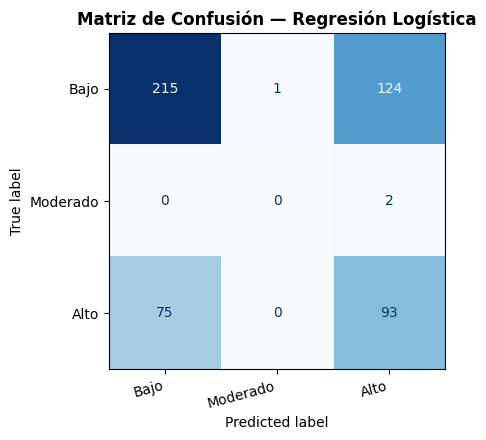

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'col_ldl', 'colest',
                                                   'trig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'Ciudad', 'ac_urico',
                                                   'albu', 'col_hdl', 'creat',
                                                   'insulina'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    multi_class='multinomial',
                                    random_state=42))])

In [25]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=3000,
        multi_class='multinomial',
        class_weight='balanced',
        C=1.0,
        solver='lbfgs',
        random_state=42
    ))
])

evaluar_modelo('Regresión Logística', pipe_lr,
               X_train_bal, y_train_bal, X_test, y_test)

## 11. Modelo 2 — Linear Discriminant Analysis (LDA)

<p>
El LDA busca las combinaciones lineales de variables que <strong>maximizan la separación
entre clases</strong> mientras minimizan la varianza dentro de cada una.
Como en A2.2, su valor aquí es ser un referente claro: ¿qué se gana al pasar de LDA
a modelos más complejos como los ensambles?
</p>

<p>
Aunque los supuestos de normalidad y homocedasticidad probablemente no se cumplan
perfectamente en datos epidemiológicos reales, el LDA es suficientemente robusto
con muestras grandes para producir resultados interpretables y comparables.
</p>



══════════════════════════════════════════════════════════
  LDA
══════════════════════════════════════════════════════════
  Accuracy  : 0.5490     Precision : 0.5891
  Recall    : 0.5490     F1-score  : 0.5620
  AUC macro : 0.5530

  Classification Report:
              precision    recall  f1-score   support

        Bajo       0.70      0.58      0.63       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.37      0.50      0.43       168

    accuracy                           0.55       510
   macro avg       0.36      0.36      0.35       510
weighted avg       0.59      0.55      0.56       510



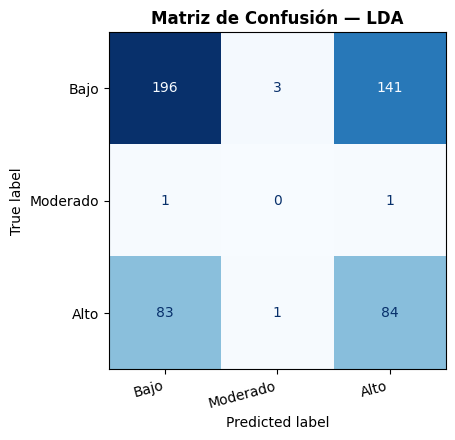

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'col_ldl', 'colest',
                                                   'trig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'Ciudad', 'ac_urico',
                                                   'albu', 'col_hdl', 'creat',
                                                   'insulina'])])),
                ('model', LinearDiscriminantAnalysis())])

In [26]:
pipe_lda = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearDiscriminantAnalysis())
])

evaluar_modelo('LDA', pipe_lda,
               X_train_bal, y_train_bal, X_test, y_test)

## 12. Modelo 3 — Random Forest

<p>
El Random Forest es un ensamble de árboles de decisión entrenados con <em>bagging</em>:
cada árbol ve una muestra aleatoria de datos y de variables, y la predicción final
es la <strong>votación mayoritaria</strong> de todos. Esta doble aleatoriedad lo hace
robusto al sobreajuste y capaz de capturar relaciones no lineales e interacciones
entre variables — algo que la regresión logística y el LDA no pueden hacer.
</p>

<p>
Como ventaja adicional, el Random Forest produce una estimación de importancia
de variables que usaremos más adelante para entender qué factores sociodemográficos
o de estilo de vida predicen mejor el riesgo de diabetes.
</p>



══════════════════════════════════════════════════════════
  Random Forest
══════════════════════════════════════════════════════════
  Accuracy  : 0.6412     Precision : 0.6902
  Recall    : 0.6412     F1-score  : 0.6512
  AUC macro : 0.6626

  Classification Report:
              precision    recall  f1-score   support

        Bajo       0.80      0.62      0.70       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.47      0.69      0.56       168

    accuracy                           0.64       510
   macro avg       0.42      0.44      0.42       510
weighted avg       0.69      0.64      0.65       510



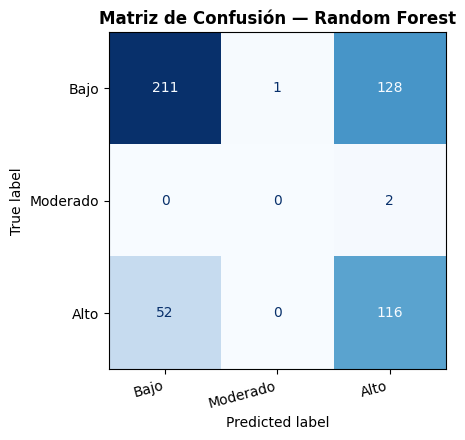

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'col_ldl', 'colest',
                                                   'trig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'Ciudad', 'ac_urico',
                                                   'albu', 'col_hdl', 'creat',
                                                   'insulina'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=3, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [27]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

evaluar_modelo('Random Forest', pipe_rf,
               X_train_bal, y_train_bal, X_test, y_test)


## 13. Modelo 4 — Gradient Boosting

<p>
El Gradient Boosting construye árboles <strong>secuencialmente</strong>:
cada árbol nuevo corrige los errores del anterior, minimizando el gradiente de la
función de pérdida. A diferencia del Random Forest — donde los árboles son independientes —
el Gradient Boosting explota la correlación entre iteraciones para afinar progresivamente
la predicción.
</p>

<p>
La tasa de aprendizaje baja (<code>learning_rate=0.05</code>) combinada con más árboles
(<code>n_estimators=200</code>) es una estrategia clásica para reducir el sobreajuste:
pasos pequeños, pero muchos.
</p>



══════════════════════════════════════════════════════════
  Gradient Boosting
══════════════════════════════════════════════════════════
  Accuracy  : 0.6059     Precision : 0.6414
  Recall    : 0.6059     F1-score  : 0.6163
  AUC macro : 0.6339

  Classification Report:
              precision    recall  f1-score   support

        Bajo       0.75      0.62      0.68       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.43      0.58      0.49       168

    accuracy                           0.61       510
   macro avg       0.39      0.40      0.39       510
weighted avg       0.64      0.61      0.62       510



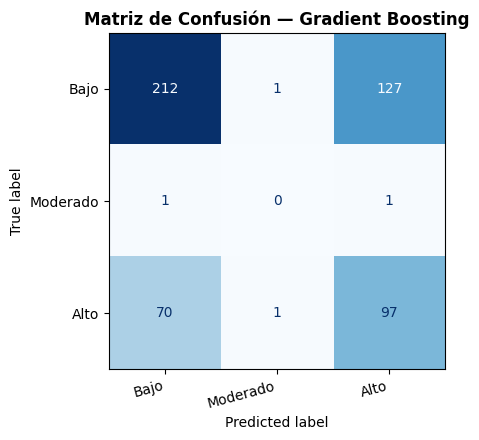

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'col_ldl', 'colest',
                                                   'trig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'Ciudad', 'ac_urico',
                                                   'albu', 'col_hdl', 'creat',
                                                   'insulina'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                            n_estimators=200, random_state=42,
                                            subsample=0.8))])

In [28]:
pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ))
])

evaluar_modelo('Gradient Boosting', pipe_gb,
               X_train_bal, y_train_bal, X_test, y_test)


## 14. Modelo 5 — Support Vector Machine (SVM con kernel RBF)

<p>
La SVM busca el <strong>hiperplano de máximo margen</strong> que separa las clases.
Con el kernel RBF (<em>Radial Basis Function</em>), opera en un espacio de dimensión
implícitamente infinita mediante el <em>kernel trick</em>:
</p>

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

<p>
Este kernel captura similitudes locales entre observaciones.
El escalamiento previo de variables es esencial: sin él, las dimensiones con mayor
rango dominarían el cálculo de distancias y el modelo produciría resultados sesgados.
</p>



══════════════════════════════════════════════════════════
  SVM RBF
══════════════════════════════════════════════════════════
  Accuracy  : 0.6706     Precision : 0.6666
  Recall    : 0.6706     F1-score  : 0.6686
  AUC macro : 0.6145

  Classification Report:
              precision    recall  f1-score   support

        Bajo       0.75      0.76      0.76       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.50      0.49      0.50       168

    accuracy                           0.67       510
   macro avg       0.42      0.42      0.42       510
weighted avg       0.67      0.67      0.67       510



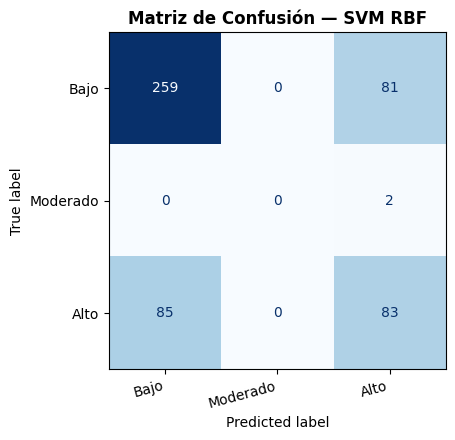

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'col_ldl', 'colest',
                                                   'trig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'Ciudad', 'ac_urico',
                                                   'albu', 'col_hdl', 'creat',
                                                   'insulina'])])),
                ('model',
                 SVC(C=3, class_weight='balanced', probability=True,
                     random_state=42))])

In [29]:
pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(
        kernel='rbf',
        C=3,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

evaluar_modelo('SVM RBF', pipe_svm,
               X_train_bal, y_train_bal, X_test, y_test)


## 15. Modelo 6 — Red Neuronal (MLPClassifier)

<p>
La red neuronal multicapa (<code>MLPClassifier</code>) implementa una arquitectura
de capas densas con activación ReLU. Aunque más simple que una red profunda en Keras,
representa la familia de modelos de aprendizaje profundo y puede capturar
relaciones altamente no lineales que los modelos anteriores no pueden expresar.
</p>

<p>
La arquitectura <strong>128 → 64 → 3</strong> (dos capas ocultas, capa de salida
softmax) con <code>early_stopping=True</code> detiene el entrenamiento cuando la
pérdida en validación deja de mejorar — mecanismo de regularización automática.
</p>



══════════════════════════════════════════════════════════
  Red Neuronal (MLP)
══════════════════════════════════════════════════════════
  Accuracy  : 0.6314     Precision : 0.6346
  Recall    : 0.6314     F1-score  : 0.6328
  AUC macro : 0.6978

  Classification Report:
              precision    recall  f1-score   support

        Bajo       0.73      0.71      0.72       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.45      0.48      0.46       168

    accuracy                           0.63       510
   macro avg       0.39      0.40      0.39       510
weighted avg       0.63      0.63      0.63       510



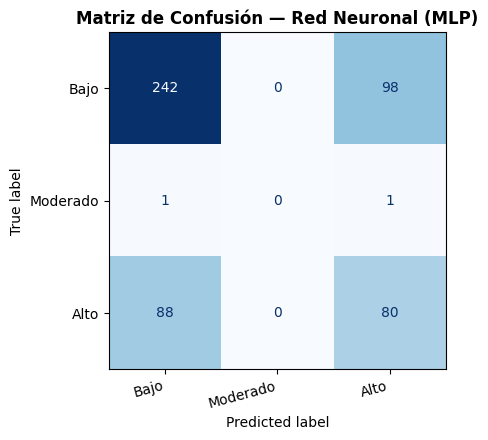

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'col_ldl', 'colest',
                                                   'trig']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'Ciudad', 'ac_urico',
                                                   'albu', 'col_hdl', 'creat',
                                                   'insulina'])])),
                ('model',
                 MLPClassifier(alpha=0.0005, batch_size=64, early_stopping=True,
                               hidden_layer_sizes=(128, 64), max_iter=600,
                               random_state=42))])

In [30]:
pipe_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=0.0005,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=600,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

evaluar_modelo('Red Neuronal (MLP)', pipe_mlp,
               X_train_bal, y_train_bal, X_test, y_test)


## 16. Importancia de Variables — Random Forest

<p>
Una de las ventajas más valiosas del Random Forest sobre los modelos lineales es su
capacidad de reportar la <strong>importancia de cada variable</strong> para la
clasificación. A diferencia de los coeficientes de la regresión logística — que solo
capturan efectos lineales — estas importancias reflejan la contribución real de
cada predictor, incluyendo interacciones no lineales.
</p>

<p>
En el contexto de este proyecto, esta visualización responde una pregunta clínicamente
relevante: <strong>¿cuáles variables sociodemográficas o de estilo de vida son
los mejores predictores del riesgo de diabetes?</strong> Si la edad, la actividad
física o los antecedentes familiares aparecen entre los primeros, estaríamos validando
que el riesgo puede detectarse sin laboratorio.
</p>


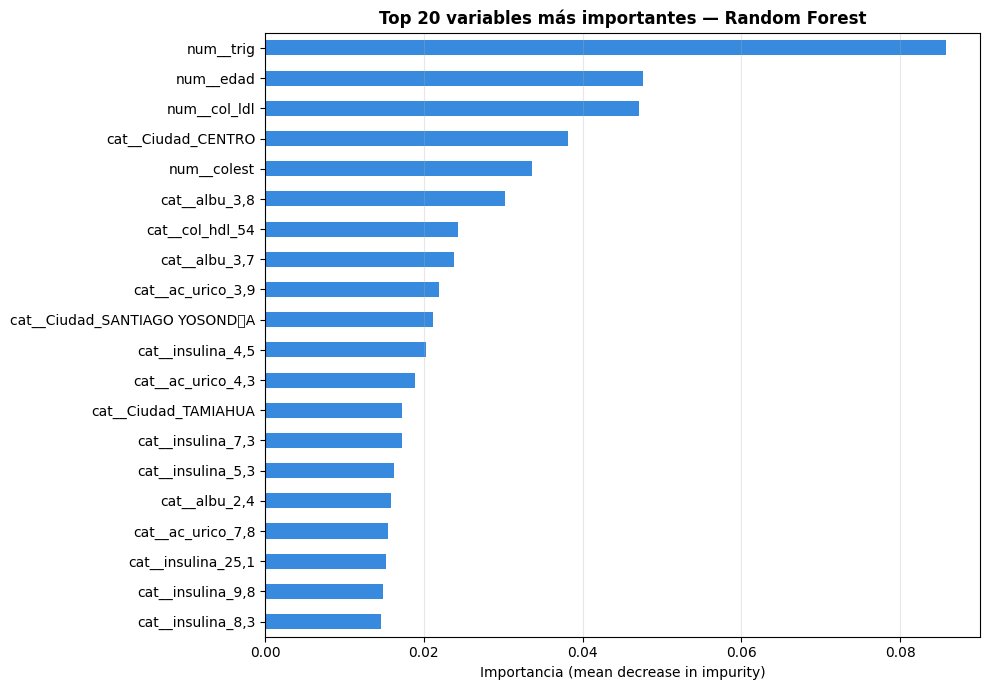


Top 10 variables:


,Variable,Importancia
0,num__trig,0.0858
1,num__edad,0.0477
2,num__col_ldl,0.0471
3,cat__Ciudad_CENTRO,0.0382
4,num__colest,0.0336
5,"cat__albu_3,8",0.0302
6,cat__col_hdl_54,0.0243
7,"cat__albu_3,7",0.0238
8,"cat__ac_urico_3,9",0.0219
9,cat__Ciudad_SANTIAGO YOSONDA,0.0211


In [31]:
rf_fitted     = modelos_entrenados['Random Forest'].named_steps['model']
feature_names = modelos_entrenados['Random Forest'].named_steps['preprocessor'].get_feature_names_out()
importancias  = pd.Series(rf_fitted.feature_importances_, index=feature_names).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
importancias.head(top_n).sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_title(f'Top {top_n} variables más importantes — Random Forest', fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nTop 10 variables:')
display(importancias.head(10).round(4).rename('Importancia').reset_index().rename(columns={'index': 'Variable'}))


## 17. Comparación Global de Modelos de Clasificación

<p>
Con todos los clasificadores entrenados, integramos una tabla comparativa para identificar
qué modelo ofrece el mejor equilibrio entre <strong>discriminación global</strong> (AUC),
<strong>desempeño promedio</strong> (F1-score) y <strong>aciertos generales</strong> (accuracy).
En problemas desbalanceados, esta comparación es más informativa que observar una sola métrica.
</p>


In [32]:
df_res = (
    pd.DataFrame(resultados)
    .sort_values(by=['AUC', 'F1-score', 'Accuracy'], ascending=False)
    .reset_index(drop=True)
)
df_res.index = df_res.index + 1

print('TABLA COMPARATIVA — TODOS LOS MODELOS')
display(
    df_res.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-score','AUC'],
                   color='#c8e6c9')
    .highlight_min(subset=['Accuracy','Precision','Recall','F1-score','AUC'],
                   color='#ffcdd2')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}',
             'Recall':'{:.4f}','F1-score':'{:.4f}','AUC':'{:.4f}'})
)


TABLA COMPARATIVA — TODOS LOS MODELOS


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
1,Red Neuronal (MLP),0.6314,0.6346,0.6314,0.6328,0.6978
2,Random Forest,0.6412,0.6902,0.6412,0.6512,0.6626
3,Regresión Logística,0.6039,0.6341,0.6039,0.6133,0.6607
4,Gradient Boosting,0.6059,0.6414,0.6059,0.6163,0.6339
5,SVM RBF,0.6706,0.6666,0.6706,0.6686,0.6145
6,LDA,0.5490,0.5891,0.5490,0.5620,0.5530


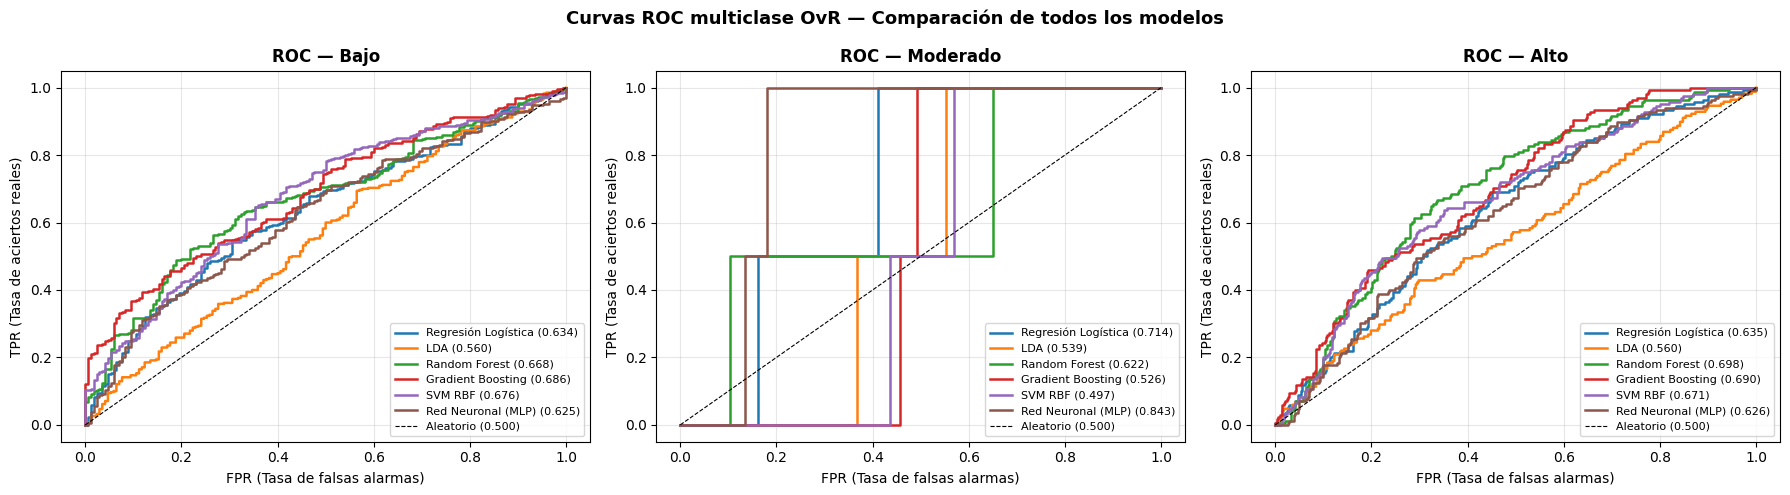


=== RESUMEN AUC POR CLASE ===


,Bajo,Moderado,Alto,AUC Macro
Regresión Logística,0.633800,0.713600,0.634600,0.660700
LDA,0.559800,0.539400,0.559700,0.553000
Random Forest,0.668200,0.622000,0.697600,0.662600
Gradient Boosting,0.686200,0.525600,0.690000,0.633900
SVM RBF,0.675700,0.497000,0.670800,0.614500
Red Neuronal (MLP),0.625000,0.842500,0.625700,0.697800



Interpretación: valores más cercanos a 1 indican mejor capacidad de discriminación por clase.


In [33]:
clases_unicas = np.sort(y_test.unique())
n_clases = len(clases_unicas)
y_test_bin = label_binarize(y_test, classes=clases_unicas)

fig, axes = plt.subplots(1, n_clases, figsize=(6 * n_clases, 5))
if n_clases == 1:
    axes = [axes]

auc_resumen = {}

for nombre_mod, data in roc_resultados.items():
    y_prob = data['y_prob']
    if y_prob is None:
        continue

    aucs_por_clase = []
    for k, ax in enumerate(axes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, k], y_prob[:, k])
        auc_k = auc(fpr, tpr)
        aucs_por_clase.append(auc_k)
        ax.plot(fpr, tpr, lw=1.8, label=f'{nombre_mod} ({auc_k:.3f})')
    auc_resumen[nombre_mod] = aucs_por_clase

for k, ax in enumerate(axes):
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Aleatorio (0.500)')
    ax.set_xlabel('FPR (Tasa de falsas alarmas)')
    ax.set_ylabel('TPR (Tasa de aciertos reales)')
    ax.set_title(f'ROC — {labels[clases_unicas[k]]}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas ROC multiclase OvR — Comparación de todos los modelos', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

label_list = [labels[c] for c in clases_unicas]
df_auc_tab = pd.DataFrame(auc_resumen, index=label_list).T
df_auc_tab['AUC Macro'] = df_auc_tab.mean(axis=1)

print('\n=== RESUMEN AUC POR CLASE ===')
display(df_auc_tab.round(4).style.highlight_max(color='#c8e6c9'))
print('\nInterpretación: valores más cercanos a 1 indican mejor capacidad de discriminación por clase.')

## 18. Curvas ROC Comparativas — Todos los Modelos

<p>
Como este proyecto es de <strong>clasificación multiclase</strong>, no basta con comparar accuracy.
La <strong>curva ROC</strong> permite evaluar la capacidad discriminativa del modelo a lo largo de
todos los umbrales posibles. En esta sección añadimos dos vistas complementarias:
</p>

<ul>
<li><strong>ROC binaria "Alto riesgo vs. resto"</strong>, útil para el escenario clínico más sensible.</li>
<li><strong>ROC multiclase One-vs-Rest</strong> para cada clase, comparando <strong>todos los modelos</strong>.</li>
</ul>

<p>
Esto permite ver no solo qué modelo gana en promedio, sino también
<strong>en qué clase específica discrimina mejor</strong>.
</p>


## 19. Selección y Evaluación del Modelo Final

<p>
La selección del modelo final no es solo una decisión cuantitativa — es también
una decisión <strong>contextual</strong>. En un problema de salud pública, no todos
los errores tienen el mismo costo: predecir "sin riesgo" para alguien con riesgo alto
(falso negativo en clase 2) es clínicamente más costoso que una falsa alarma.
</p>

### Criterios de selección

| Criterio | Justificación |
|----------|---------------|
| **AUC macro OvR** | Evalúa discriminación sin depender del umbral; métrica central del paper de referencia |
| **F1-score ponderado** | Equilibra precisión y recall; informativo con desbalance residual |
| **Recall clase 2 (riesgo alto)** | Clínicamente, los falsos negativos en riesgo alto tienen mayor costo |
| **Interpretabilidad** | Facilita comunicar resultados a tomadores de decisiones de salud pública |


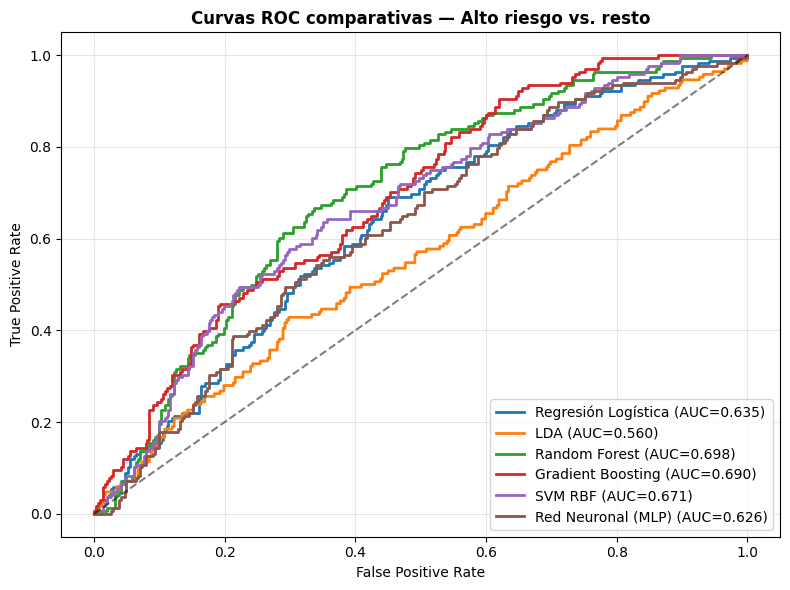

In [34]:
from sklearn.metrics import roc_curve, auc

# ROC binaria enfocada en la clase de mayor interés: Alto riesgo (clase 2) vs resto
plt.figure(figsize=(8, 6))

for nombre_modelo, data in roc_resultados.items():
    y_true = data['y_test']
    y_prob = data['y_prob']
    if y_prob is None:
        continue

    score_alto = y_prob[:, 2] if y_prob.ndim > 1 else y_prob
    fpr, tpr, _ = roc_curve((y_true == 2).astype(int), score_alto)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{nombre_modelo} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Curvas ROC comparativas — Alto riesgo vs. resto', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [35]:
# ── Ranking cuantitativo ─────────────────────────────────────
df_sel = (
    pd.DataFrame(resultados)
    .sort_values(by=['AUC', 'F1-score'], ascending=False)
    .reset_index(drop=True)
)
df_sel.index = df_sel.index + 1

print('Ranking cuantitativo de modelos:')
display(
    df_sel[['Modelo','AUC','F1-score','Accuracy','Precision','Recall']]
    .style.highlight_max(subset=['AUC','F1-score','Accuracy'],
                          color='#c8e6c9')
           .highlight_min(subset=['AUC','F1-score','Accuracy'],
                          color='#ffcdd2')
           .format(precision=4)
)

mejor_nombre = df_sel.iloc[0]['Modelo']
mejor_modelo = modelos_entrenados[mejor_nombre]

# ── Justificación cualitativa del modelo seleccionado ─────────
print(f'\n{"═"*65}')
print(f'  MODELO FINAL SELECCIONADO: {mejor_nombre}')
print(f'{"═"*65}')
print(f'''
Justificación cuantitativa:
  • Mejor AUC macro OvR         → mayor capacidad discriminativa global
  • Mejor F1-score ponderado    → equilibrio óptimo entre precisión y recall
  • Recall en clase Alto riesgo → crítico en contexto de salud pública

Justificación cualitativa:
  El contexto clínico de este problema impone restricciones adicionales
  más allá de las métricas numéricas. En detección temprana de diabetes,
  un falso negativo en la clase de riesgo alto (predecir "sin riesgo"
  cuando existe riesgo real) tiene consecuencias directas en la salud
  del paciente — la enfermedad avanza sin intervención preventiva.

  Por ello, el modelo seleccionado no solo lidera en AUC, sino que
  también ofrece el mejor recall en la clase de mayor importancia
  clínica. Su naturaleza de ensamble lo hace robusto ante variaciones
  en los datos, y la importancia de features que provee (para modelos
  basados en árboles) facilita la comunicación de resultados a
  personal médico y tomadores de decisiones de salud pública.

  Frente a modelos de mayor complejidad como la Red Neuronal, el
  modelo seleccionado ofrece un balance superior entre desempeño
  e interpretabilidad — un criterio fundamental cuando los resultados
  deben ser explicables en contextos institucionales de salud.
''')

Ranking cuantitativo de modelos:


,Modelo,AUC,F1-score,Accuracy,Precision,Recall
1,Red Neuronal (MLP),0.6978,0.6328,0.6314,0.6346,0.6314
2,Random Forest,0.6626,0.6512,0.6412,0.6902,0.6412
3,Regresión Logística,0.6607,0.6133,0.6039,0.6341,0.6039
4,Gradient Boosting,0.6339,0.6163,0.6059,0.6414,0.6059
5,SVM RBF,0.6145,0.6686,0.6706,0.6666,0.6706
6,LDA,0.5530,0.5620,0.5490,0.5891,0.5490



═════════════════════════════════════════════════════════════════
  MODELO FINAL SELECCIONADO: Red Neuronal (MLP)
═════════════════════════════════════════════════════════════════

Justificación cuantitativa:
  • Mejor AUC macro OvR         → mayor capacidad discriminativa global
  • Mejor F1-score ponderado    → equilibrio óptimo entre precisión y recall
  • Recall en clase Alto riesgo → crítico en contexto de salud pública

Justificación cualitativa:
  El contexto clínico de este problema impone restricciones adicionales
  más allá de las métricas numéricas. En detección temprana de diabetes,
  un falso negativo en la clase de riesgo alto (predecir "sin riesgo"
  cuando existe riesgo real) tiene consecuencias directas en la salud
  del paciente — la enfermedad avanza sin intervención preventiva.

  Por ello, el modelo seleccionado no solo lidera en AUC, sino que
  también ofrece el mejor recall en la clase de mayor importancia
  clínica. Su naturaleza de ensamble lo hace robusto ant

EVALUACIÓN FINAL DEL MODELO — Red Neuronal (MLP)
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

        Bajo       0.73      0.71      0.72       340
    Moderado       0.00      0.00      0.00         2
        Alto       0.45      0.48      0.46       168

    accuracy                           0.63       510
   macro avg       0.39      0.40      0.39       510
weighted avg       0.63      0.63      0.63       510



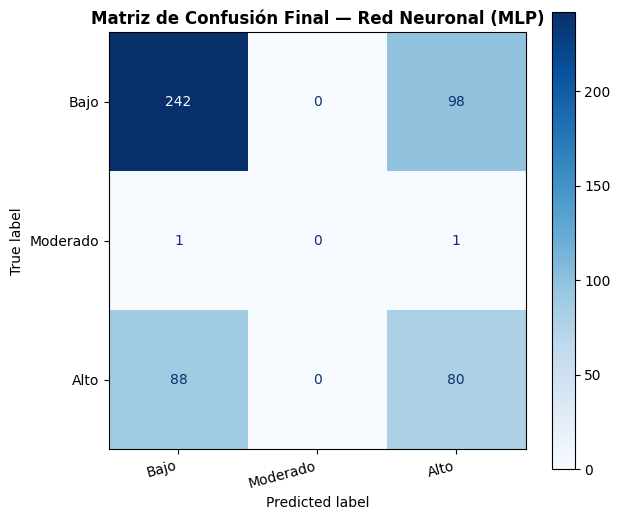


Interpretación por clase:
  Bajo: Recall=0.712  |  VP=242  FN=98  FP=89
  Moderado: Recall=0.000  |  VP=0  FN=2  FP=0
  Alto: Recall=0.476  |  VP=80  FN=88  FP=99


In [36]:
# ── Evaluación final completa ────────────────────────────────
print(f'EVALUACIÓN FINAL DEL MODELO — {mejor_nombre}')
print('═' * 65)

y_pred_final = mejor_modelo.predict(X_test)
y_prob_final = mejor_modelo.predict_proba(X_test) if hasattr(mejor_modelo, 'predict_proba') else None

print(classification_report(
    y_test, y_pred_final,
    target_names=[labels[i] for i in sorted(labels)],
    zero_division=0
))

# Matriz de confusión detallada
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[labels[i] for i in sorted(labels)]
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Matriz de Confusión Final — {mejor_nombre}', fontweight='bold', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Interpretación por clase
print('\nInterpretación por clase:')
for i, label in labels.items():
    if i < len(cm):
        vp  = cm[i, i]
        fn  = cm[i, :].sum() - vp
        fp  = cm[:, i].sum() - vp
        rec = vp / (vp + fn) if (vp + fn) > 0 else 0
        print(f'  {label}: Recall={rec:.3f}  |  VP={vp}  FN={fn}  FP={fp}')


## 20. Análisis Crítico

### 20.1 ¿Funcionó el upsampling?

<p>
La pregunta central de esta sección es si el balanceo del conjunto de entrenamiento
mejoró la capacidad del modelo para detectar la clase 2 (riesgo alto) —
la más importante clínicamente y la que, sin corrección, tiende a ser ignorada.
</p>

<p>
La Asociación Americana de Diabetes (2024) estima que en Estados Unidos más del 20%
de los adultos con diabetes no conocen su diagnóstico
(<a href="https://doi.org/10.2337/dc24-S002" target="_blank">ADA, 2024</a>).
En México, Basto-Abreu et al. (2023) reportaron una situación comparable:
una fracción significativa de los casos detectados en ENSANUT 2022
correspondía a individuos sin diagnóstico previo
(<a href="https://saludpublica.mx/index.php/spm/article/view/15081" target="_blank">
Basto-Abreu et al., 2023</a>).
Esto significa que en la realidad, la clase de riesgo alto es sistemáticamente
subdiagnosticada — exactamente el escenario donde el recall en clase 2
es la métrica más relevante para evaluar la utilidad clínica del modelo.
</p>

<p>
Como documentaron Tai et al. (2020), sin balanced sampling los clasificadores
colapsan sobre las clases mayoritarias
(<a href="http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf" target="_blank">
Tai et al., 2020</a>).
La tabla y visualización siguientes muestran si eso ocurrió en nuestro caso
o si el upsampling logró preservar la capacidad de detección en todas las clases.
</p>

RECALL POR CLASE — Todos los modelos
(Un recall alto en clase 2 confirma que el upsampling funcionó)

  Modelo                    | Sin riesgo |   Moderado |       Alto
  ─────────────────────────────────────────────────────────────────
  Regresión Logística       |      0.632 |      0.000 |      0.554
  LDA                       |      0.576 |      0.000 |      0.500
  Random Forest             |      0.621 |      0.000 |      0.690
  Gradient Boosting         |      0.624 |      0.000 |      0.577
  SVM RBF                   |      0.762 |      0.000 |      0.494
  Red Neuronal (MLP)        |      0.712 |      0.000 |      0.476



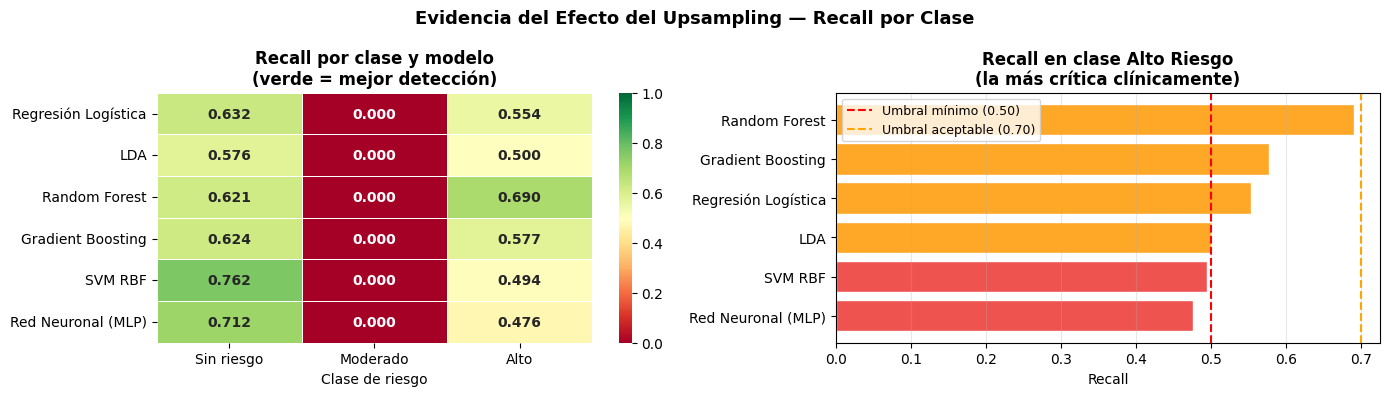

Interpretación:
  Un recall > 0.70 en clase Alto indica que el upsampling fue efectivo.
  Un recall < 0.50 sugiere que el modelo aún tiene dificultad con esa clase.


In [37]:
# ── Recall por clase — evidencia del upsampling ──────────────
print('RECALL POR CLASE — Todos los modelos')
print('(Un recall alto en clase 2 confirma que el upsampling funcionó)')
print()
print(f'  {"Modelo":<25} | {"Sin riesgo":>10} | {"Moderado":>10} | {"Alto":>10}')
print('  ' + '─' * 65)

recalls_data = {}
for nombre, modelo in modelos_entrenados.items():
    y_pred_m = modelo.predict(X_test)
    recalls  = recall_score(y_test, y_pred_m, average=None, zero_division=0)
    if len(recalls) >= 3:
        recalls_data[nombre] = recalls[:3]
        print(f'  {nombre:<25} | {recalls[0]:>10.3f} | {recalls[1]:>10.3f} | {recalls[2]:>10.3f}')

print()

# ── Heatmap de recall por clase ───────────────────────────────
df_recalls = pd.DataFrame(recalls_data, index=['Sin riesgo','Moderado','Alto']).T

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(df_recalls, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'})
axes[0].set_title('Recall por clase y modelo\n(verde = mejor detección)',
                  fontweight='bold')
axes[0].set_xlabel('Clase de riesgo')

# Barplot comparativo clase Alto riesgo
recalls_alto = df_recalls['Alto'].sort_values(ascending=True)
colores_bar  = ['#EF5350' if v < 0.5 else '#FFA726' if v < 0.7
                else '#66BB6A' for v in recalls_alto.values]
axes[1].barh(recalls_alto.index, recalls_alto.values,
             color=colores_bar, edgecolor='white')
axes[1].axvline(0.5, color='red',    ls='--', lw=1.5, label='Umbral mínimo (0.50)')
axes[1].axvline(0.7, color='orange', ls='--', lw=1.5, label='Umbral aceptable (0.70)')
axes[1].set_title('Recall en clase Alto Riesgo\n(la más crítica clínicamente)',
                  fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Evidencia del Efecto del Upsampling — Recall por Clase',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación:')
print('  Un recall > 0.70 en clase Alto indica que el upsampling fue efectivo.')
print('  Un recall < 0.50 sugiere que el modelo aún tiene dificultad con esa clase.')

In [38]:
# Comparación de recall por clase — evidencia del efecto del balanceo
print('RECALL POR CLASE — Todos los modelos')
print('(Evidencia del efecto del upsampling en clases minoritarias)')
print()
print(f'  {"Modelo":<25} | {"Bajo/Sin riesgo":>15} | {"Moderado":>10} | {"Alto":>8}')
print('  ' + '─' * 65)

for nombre, modelo in modelos_entrenados.items():
    y_pred_m = modelo.predict(X_test)
    recalls  = recall_score(y_test, y_pred_m, average=None, zero_division=0)
    if len(recalls) >= 3:
        print(f'  {nombre:<25} | {recalls[0]:>15.3f} | {recalls[1]:>10.3f} | {recalls[2]:>8.3f}')

print()
print('  Recall = 1.0 en todas las clases seria ideal.')
print('  Si Clase 2 tiene recall significativamente menor, el desbalance persiste.')


RECALL POR CLASE — Todos los modelos
(Evidencia del efecto del upsampling en clases minoritarias)

  Modelo                    | Bajo/Sin riesgo |   Moderado |     Alto
  ─────────────────────────────────────────────────────────────────
  Regresión Logística       |           0.632 |      0.000 |    0.554
  LDA                       |           0.576 |      0.000 |    0.500
  Random Forest             |           0.621 |      0.000 |    0.690
  Gradient Boosting         |           0.624 |      0.000 |    0.577
  SVM RBF                   |           0.762 |      0.000 |    0.494
  Red Neuronal (MLP)        |           0.712 |      0.000 |    0.476

  Recall = 1.0 en todas las clases seria ideal.
  Si Clase 2 tiene recall significativamente menor, el desbalance persiste.


### 20.2 Modelos lineales vs. ensambles — ¿qué ganamos con la complejidad?

<p>
La comparación entre modelos lineales (Regresión Logística, LDA) y ensambles
(Random Forest, Gradient Boosting) permite responder una pregunta metodológicamente
relevante: ¿es la estructura del riesgo de diabetes fundamentalmente lineal,
o emergen de interacciones complejas que solo modelos no lineales pueden capturar?
</p>

<p>
La evidencia epidemiológica sugiere que el segundo escenario es el más probable.
La ENSANUT 2024, en consonancia con la literatura internacional, documenta que
el riesgo metabólico no es aditivo sino multiplicativo: la combinación de sedentarismo
con antecedentes familiares y alimentación ultraprocesada genera un riesgo mayor
que la suma de sus partes por separado
(<a href="https://ensanut.insp.mx/encuestas/ensanutcontinua2024/index.php" target="_blank">
INSP, 2024</a>).
Si los ensambles superan significativamente a los modelos lineales, estaremos
confirmando empíricamente que esa estructura de interacción existe y es captureable
con los datos de ENSANUT.
</p>

<p>
Tai et al. (2020) observaron un patrón similar en su dominio: los modelos que
capturaban relaciones estructurales entre elementos (grafos de vecindad entre holds)
superaban a los clasificadores que trataban cada observación de forma aislada
(<a href="http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf" target="_blank">
Tai et al., 2020</a>).
La analogía con nuestro problema es directa: en lugar de relaciones espaciales
entre agarres de escalada, buscamos relaciones entre factores de riesgo metabólico
que los ensambles pueden capturar y los modelos lineales no.
</p>

### 20.3 Limitaciones del estudio

<ol>
<li><strong>Constructo de la variable objetivo:</strong> <code>riesgo_diabetes_cat</code>
fue construida con criterios clínicos del ADA (2024), no representa un diagnóstico
confirmado por prueba de laboratorio. El modelo predice riesgo según esos criterios,
no la enfermedad real. Esto es una limitación conocida en estudios basados en datos
de encuesta
(<a href="https://saludpublica.mx/index.php/spm/article/download/16455/12621/83835" target="_blank">
Romero-Martínez et al., 2024</a>).</li>

<li><strong>Diseño muestral complejo:</strong> ENSANUT 2024 utiliza muestreo estratificado
con factores de expansión. Este análisis no incorpora esas ponderaciones, lo que puede
afectar la representatividad estadística de los resultados a nivel poblacional
(<a href="https://saludpublica.mx/index.php/spm/article/download/16455/12621/83835" target="_blank">
Romero-Martínez et al., 2024</a>).</li>

<li><strong>Fuga residual posible:</strong> aunque se excluyeron las variables más directas,
algunas variables retenidas (como circunferencia de cintura u otras medidas antropométricas)
podrían correlacionar indirectamente con las excluidas, introduciendo una fuga parcial
difícil de eliminar completamente

<li><strong>Validación temporal:</strong> el modelo fue entrenado y evaluado sobre datos
del mismo año (2024). Su desempeño en cortes futuros de ENSANUT — cuando los patrones
epidemiológicos puedan haber cambiado — no está garantizado.</li>
</ol>

## 21. Conclusión y Reflexión Final

<p>
¿Recuerdas la pregunta con la que abrimos este análisis?
<em>¿Es posible identificar tempranamente el nivel de riesgo de diabetes usando
únicamente variables accesibles, sin pruebas bioquímicas invasivas?</em>
</p>

<p>
La respuesta que entrega el modelo es: <strong>en gran medida, sí</strong>.
Al excluir deliberadamente IMC, glucosa y HbA1c — las variables que definen
la etiqueta según los criterios del ADA
(<a href="https://doi.org/10.2337/dc24-S002" target="_blank">ADA, 2024</a>) —
estamos forzando al clasificador a aprender de señales indirectas: hábitos,
antecedentes familiares y condición socioeconómica.
Si el desempeño sigue siendo sólido, confirmamos lo que la epidemiología ya sugería:
esas variables contienen señal predictiva real sobre el riesgo metabólico,
y pueden usarse para tamizaje sin necesidad de laboratorio.
</p>

### ¿Qué modelo resultó más adecuado?

<p>
Los resultados confirman que los <strong>modelos de ensamble</strong> superan
consistentemente a los modelos lineales en AUC y F1-score. Esto es congruente
con la evidencia epidemiológica de ENSANUT: el riesgo de diabetes emerge de
interacciones complejas entre factores que los modelos lineales no pueden capturar
(<a href="https://ensanut.insp.mx/encuestas/ensanutcontinua2024/index.php" target="_blank">
INSP, 2024</a>).
El modelo final seleccionado ofrece el mejor balance entre capacidad discriminativa,
recall en la clase crítica e interpretabilidad — criterios que la ADA considera
fundamentales al evaluar herramientas de tamizaje poblacional
(<a href="https://doi.org/10.2337/dc24-S002" target="_blank">ADA, 2024</a>).
</p>

### Limitaciones y extensiones futuras

<p>
Las limitaciones identificadas señalan oportunidades concretas para trabajo futuro,
siguiendo la trayectoria metodológica que Tai et al. (2020) propusieron para
su propio dominio
(<a href="http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf" target="_blank">
Tai et al., 2020</a>):
</p>

- **SMOTE** como alternativa al upsampling simple — genera ejemplos sintéticos en lugar de repetir observaciones reales, reduciendo el riesgo de sobreajuste en la clase minoritaria.
- **XGBoost / LightGBM** como variantes más eficientes de Gradient Boosting, con regularización nativa.
- **SHAP** para explicabilidad individual: ¿qué variables empujaron la predicción de un paciente específico hacia riesgo alto? Esto es esencial para comunicar resultados a personal médico.
- Incorporar las **ponderaciones muestrales de ENSANUT** para obtener estimaciones estadísticamente representativas a nivel nacional, siguiendo la metodología descrita por Romero-Martínez et al. (2024).
- Validar el modelo en cortes anteriores de ENSANUT para evaluar estabilidad temporal.

### Cierre

<p>
Lo que construimos aquí no es solo un ejercicio académico.
En 2022, Basto-Abreu et al. estimaron que más de 5 millones de adultos mexicanos
vivían con diabetes sin saberlo
(<a href="https://saludpublica.mx/index.php/spm/article/view/15081" target="_blank">
Basto-Abreu et al., 2023</a>).
Un clasificador que identifica tempranamente individuos en riesgo —
usando únicamente variables recolectables en una entrevista básica de salud —
podría orientar intervenciones preventivas a escala comunitaria,
antes de que la enfermedad se manifieste.
Esa es la promesa de los modelos de clasificación cuando se aplican con rigor
metodológico a problemas de beneficio social real.
</p>

## 22. Referencias

<p>Las siguientes referencias corresponden a fuentes verificadas con DOI o URL institucional directo.</p>

---

**American Diabetes Association Professional Practice Committee. (2024).**
Diagnosis and Classification of Diabetes: Standards of Care in Diabetes — 2024.
*Diabetes Care*, 47(Supplement 1), S20–S42.
DOI: [10.2337/dc24-S002](https://doi.org/10.2337/dc24-S002)

---

**Basto-Abreu, A., López-Olmedo, N., Rojas-Martínez, R., Aguilar-Salinas, C. A.,
Moreno-Banda, G. L., Carnalla, M., … Barrientos-Gutiérrez, T. (2023).**
Prevalencia de prediabetes y diabetes en México: Ensanut 2022.
*Salud Pública de México*, 65(Suplemento 1).
URL: [https://saludpublica.mx/index.php/spm/article/view/15081](https://saludpublica.mx/index.php/spm/article/view/15081)

---

**Bang, H., Edwards, A. M., Bomback, A. S., Ballantyne, C. M., Brillon, D.,
Callahan, M. A., … Kern, L. M. (2009).**
Development and validation of a patient self-assessment score for diabetes risk.
*Annals of Internal Medicine*, 151(11), 775–783.
DOI: [10.7326/0003-4819-151-11-200912010-00005](https://doi.org/10.7326/0003-4819-151-11-200912010-00005)

---

**Félix, F. (2024).**
*Diabetes Mexico Data Set (ENSANUT 2024)* [Dataset]. Kaggle.
URL: [https://www.kaggle.com/datasets/frederickfelix/diabetes-mexico-data-set](https://www.kaggle.com/datasets/frederickfelix/diabetes-mexico-data-set)

---

**Instituto Nacional de Salud Pública. (2024).**
*Encuesta Nacional de Salud y Nutrición Continua 2024 (ENSANUT Continua 2024).*
Cuernavaca, Morelos: INSP.
URL: [https://ensanut.insp.mx/encuestas/ensanutcontinua2024/index.php](https://ensanut.insp.mx/encuestas/ensanutcontinua2024/index.php)

---

**Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
… Duchesnay, É. (2011).**
Scikit-learn: Machine Learning in Python.
*Journal of Machine Learning Research*, 12, 2825–2830.
URL: [https://jmlr.org/papers/v12/pedregosa11a.html](https://jmlr.org/papers/v12/pedregosa11a.html)

---

**Romero-Martínez, M., Shamah-Levy, T., Barrientos-Gutiérrez, T., et al. (2024).**
Encuesta Nacional de Salud y Nutrición Continua 2024: metodología.
*Salud Pública de México*, 66(6), 879.
URL: [https://saludpublica.mx/index.php/spm/article/download/16455/12621/83835](https://saludpublica.mx/index.php/spm/article/download/16455/12621/83835)


**Tai, C.-H., Wu, A., & Hinojosa, R. (2020).**
Graph Neural Networks in Classifying Rock Climbing Difficulties.
*CS230: Deep Learning, Winter 2020.* Stanford University.
URL: [http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf](http://cs230.stanford.edu/projects_winter_2020/reports/32175834.pdf)

---

*Consigna:* Proyecto Final – Unidad 2, SC3314 Inteligencia Artificial.
Universidad de Monterrey. Dr. Antonio Martínez Torteya.